_________________________________________可视化部分（初初版很潦草）


# 3. Visualization of Collected Data

## 3.1 Data Preprocessing and Univariate Analysis

In this section, we present the visualization of the collected data to gain intuitive insights into the mechanism of the WeChat Red Envelope (WRE). We collected data from a 3-person group with a fixed total amount of 5.00 RMB per round. The dataset records the amount received by the 1st, 2nd, and 3rd grabbers respectively.

Before diving into complex modeling, it is essential to observe the global distribution of the allocated amounts. This helps us check for skewness, kurtosis, and whether the data conforms to standard distributions (e.g., Uniform or Normal).

In [2]:
!pip install pandas numpy matplotlib seaborn scipy

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 设置绘图风格 (学术风格)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = ['Arial'] # 防止中文乱码，或者使用英文字体
plt.rcParams['axes.unicode_minus'] = False

# 读取数据 (请确保文件名与你的本地文件一致)
# 假设你的文件名为 'red_packet_data.csv'
df = pd.read_csv('red_packet_data.csv')

# 数据清洗：提取核心的三列数据 (Order of grabbing)
# first, second, third 代表抢的顺序
df_sequence = df[['first', 'second', 'third']]

# 将所有金额展平到一个数组中，用于观察“全局分布”
all_amounts = df_sequence.values.flatten()

# 打印基本统计信息
print(f"Total rounds: {len(df)}")
print(f"Total samples: {len(all_amounts)}")
print(f"Mean: {np.mean(all_amounts):.4f}")
print(f"Std Dev: {np.std(all_amounts):.4f}")
print(f"Max: {np.max(all_amounts)}, Min: {np.min(all_amounts)}")

df.head() # 展示前几行数据

Total rounds: 100
Total samples: 300
Mean: 1.6667
Std Dev: 1.0233
Max: 4.44, Min: 0.02


,round,amount,first,second,third,Unnamed: 5,cyb,dlp,str
0,1,5.0,2.77,1.12,1.11,NaN,2.77,1.12,1.11
1,2,5.0,2.86,1.12,1.02,NaN,2.86,1.12,1.02
2,3,5.0,2.16,1.66,1.18,NaN,2.16,1.66,1.18
3,4,5.0,1.48,0.17,3.35,NaN,1.48,0.17,3.35
4,5,5.0,2.48,0.99,1.53,NaN,2.48,0.99,1.53


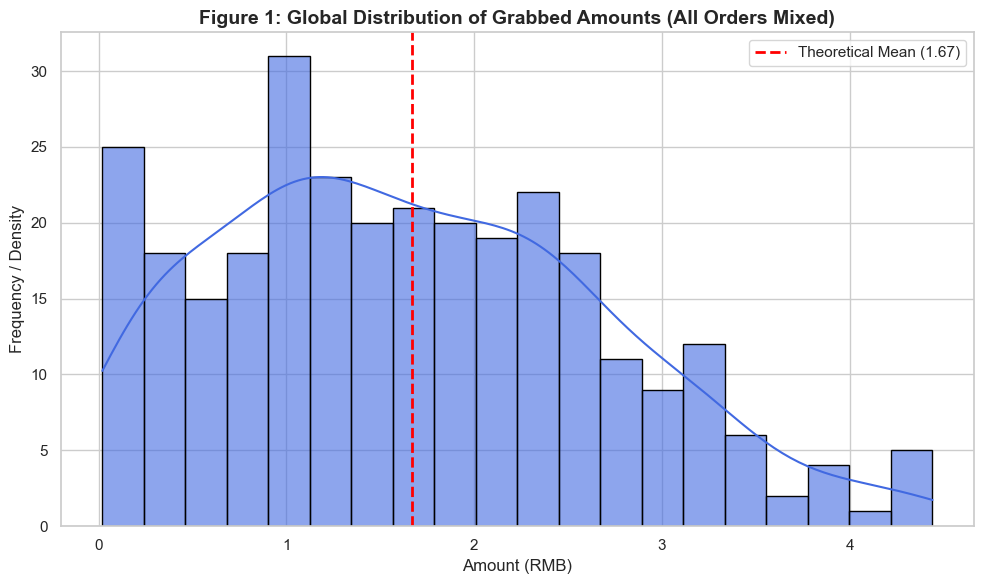

In [6]:
# 创建画布
plt.figure(figsize=(10, 6))

# 绘制直方图和核密度估计 (KDE)
# binwidth 可以根据数据量调整，这里设为 0.2 或 0.1 比较合适
sns.histplot(all_amounts, kde=True, bins=20, color='royalblue', edgecolor='black', alpha=0.6)

# 添加辅助线：均值 (Expectation = 5 / 3 = 1.67)
expected_mean = 5.0 / 3.0
plt.axvline(expected_mean, color='red', linestyle='--', linewidth=2, label=f'Theoretical Mean ({expected_mean:.2f})')

# 图表装饰
plt.title('Figure 1: Global Distribution of Grabbed Amounts (All Orders Mixed)', fontsize=14, fontweight='bold')
plt.xlabel('Amount (RMB)', fontsize=12)
plt.ylabel('Frequency / Density', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

### Observation 1: Global Distribution Characteristics

Figure 1 illustrates the distribution of all grabbed amounts (mixing the results of the 1st, 2nd, and 3rd participants).

* **Shape:** The distribution does not appear to be a standard bell-shaped Normal distribution. It shows a relatively flat or slightly irregular shape across a wide range (0 to 3.5 RMB).
* **Mean:** The data centers around the theoretical mean ($E[X] \approx 1.67$ RMB), which confirms the fairness of the system in the long run (Law of Large Numbers).
* **Range:** The values span from near 0.01 to over 3.00, covering a significant portion of the total amount.

This "mixed" visualization, however, might hide the underlying mechanism dependent on the sequence. Therefore, we further break down the data by the order of grabbing.

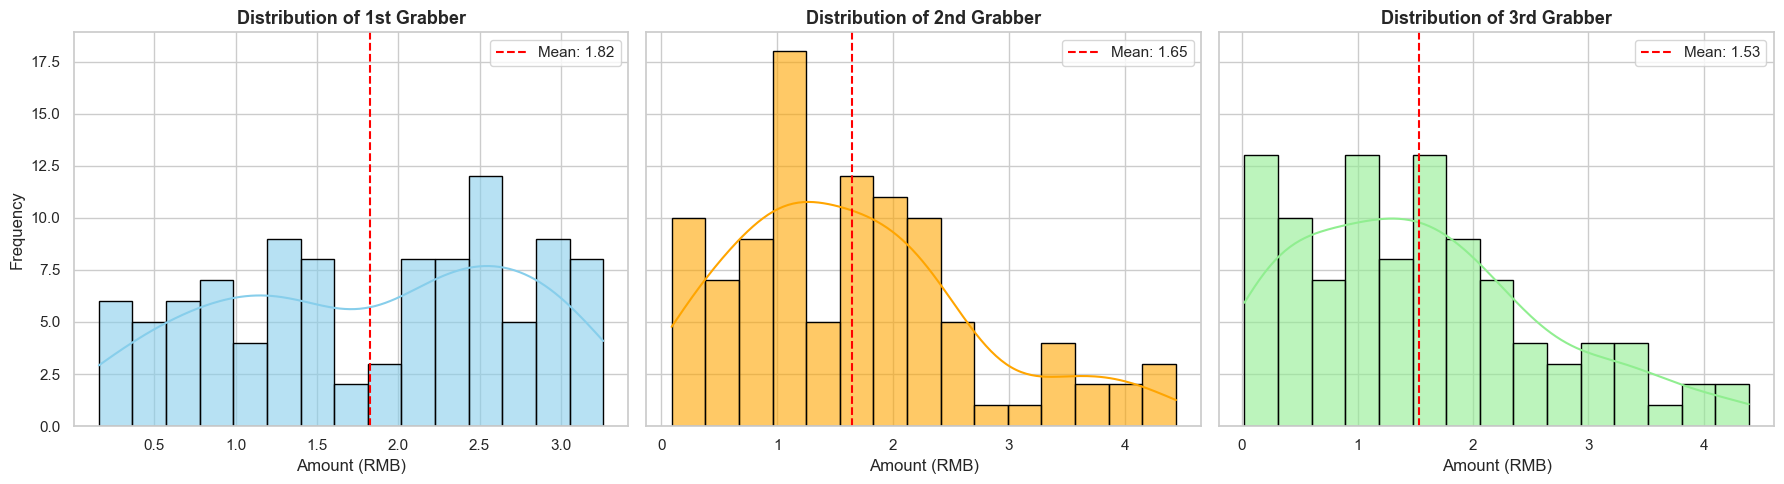

In [7]:
# 创建 1行3列 的子图
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# 定义颜色列表区分不同顺位
colors = ['skyblue', 'orange', 'lightgreen']
titles = ['1st Grabber', '2nd Grabber', '3rd Grabber']

# 循环绘制三个顺位的分布
for i, col_name in enumerate(['first', 'second', 'third']):
    # 绘制直方图 + KDE
    sns.histplot(df[col_name], kde=True, bins=15, ax=axes[i], 
                 color=colors[i], edgecolor='black', alpha=0.6)
    
    # 标出该位置的样本均值
    sample_mean = df[col_name].mean()
    axes[i].axvline(sample_mean, color='red', linestyle='--', label=f'Mean: {sample_mean:.2f}')
    
    # 装饰
    axes[i].set_title(f'Distribution of {titles[i]}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Amount (RMB)')
    if i == 0:
        axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.tight_layout()
plt.show()

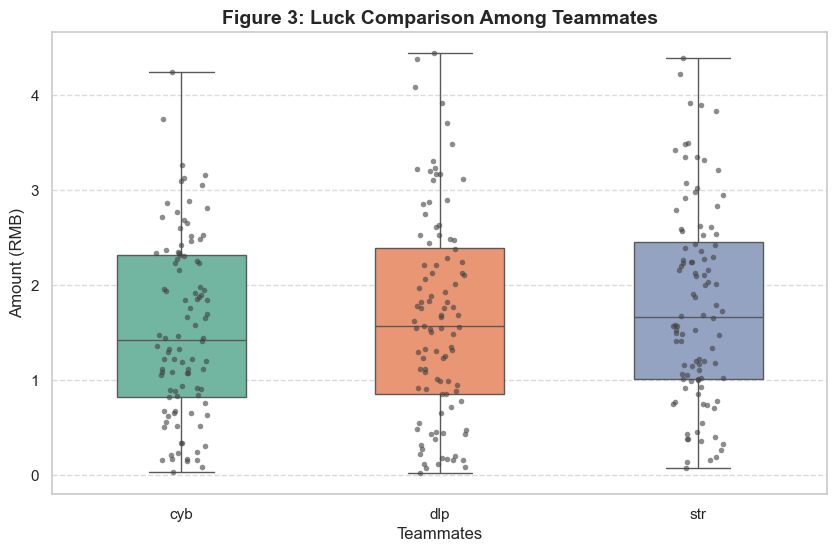

In [8]:
# 可视化具体组员的分布 (Boxplot)
plt.figure(figsize=(10, 6))

# 准备绘图数据
df_members = df[['cyb', 'dlp', 'str']]

# 绘制箱线图
sns.boxplot(data=df_members, palette="Set2", width=0.5)
sns.stripplot(data=df_members, color=".25", size=4, alpha=0.6) # 添加散点以显示具体数据分布

plt.title('Figure 3: Luck Comparison Among Teammates', fontsize=14, fontweight='bold')
plt.ylabel('Amount (RMB)')
plt.xlabel('Teammates')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Observation 2: The Impact of Sequence

Decomposing the data by the order of grabbing (Figure 2) reveals distinct patterns:

1.  [cite_start]**The 1st Grabber:** The distribution appears remarkably flat, resembling a **Uniform Distribution**[cite: 12]. The range seems to be roughly $[0, 3.33]$, which is close to $[0, 2 \times \frac{5}{3}]$. This gives us a strong hint towards the "Double Mean" hypothesis.
2.  **The 2nd Grabber:** The distribution starts to shift and looks different from the first one. The variance seems to change.
3.  **The 3rd Grabber:** As the last person, their amount is deterministically decided by the remaining money ($M - X_1 - X_2$). The distribution appears to have a higher variance or a different mode.

Figure 3 (Teammates Comparison) shows that despite the sequence difference, the median amounts received by specific users are relatively close, suggesting that the random assignment of "who grabs first" averages out the luck over time.